Using Colab cache for faster access to the 'mnist-dataset' dataset.
MSE for first 5 samples:
0.016936671
0.020190308
0.015057873
0.016248371
0.0148078045


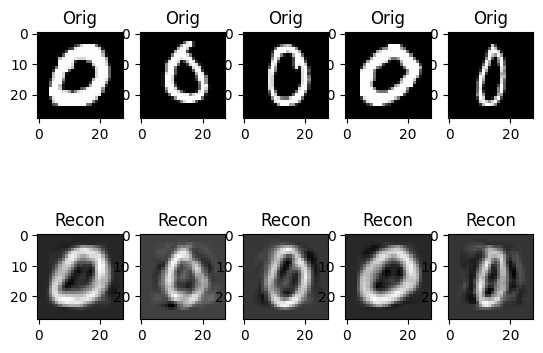

LDA Train Accuracy: 0.97
LDA Test Accuracy: 0.9433333333333334
QDA Train Accuracy: 0.9933333333333333
QDA Test Accuracy: 0.9733333333333334


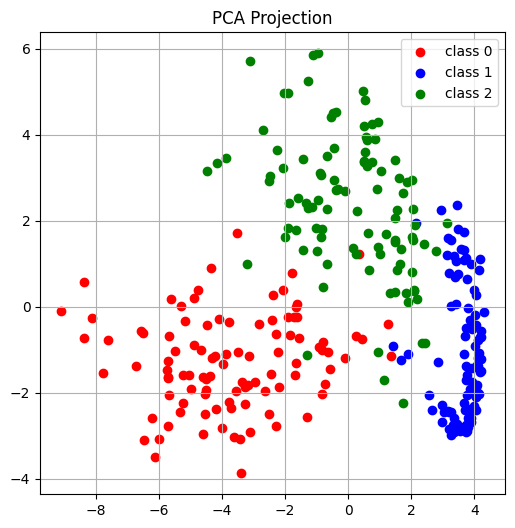

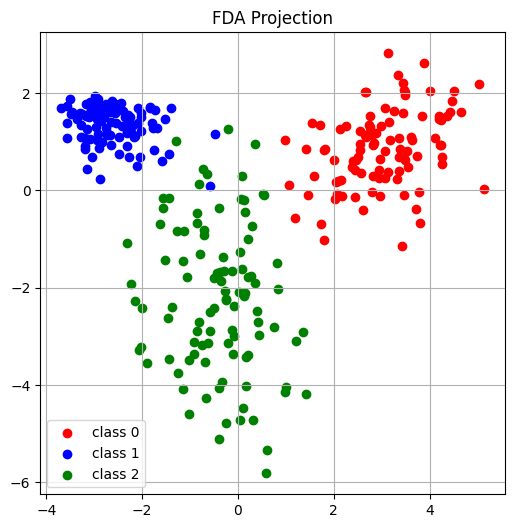

In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from os.path import join
import kagglehub

# ==========================================================
# MNIST DATA LOADER
# ==========================================================

class MnistDataloader(object):

    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):

        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath


    def read_images_labels(self, images_filepath, labels_filepath):

        with open(labels_filepath, 'rb') as file:
            struct.unpack(">II", file.read(8))
            labels = np.frombuffer(file.read(), dtype=np.uint8)

        with open(images_filepath, 'rb') as file:
            struct.unpack(">IIII", file.read(16))
            images = np.frombuffer(file.read(), dtype=np.uint8).reshape(-1,28,28)

        return images, labels


    def load_data(self):

        x_train, y_train = self.read_images_labels(self.training_images_filepath,
                                                   self.training_labels_filepath)

        x_test, y_test = self.read_images_labels(self.test_images_filepath,
                                                 self.test_labels_filepath)

        return (x_train, y_train), (x_test, y_test)



# ==========================================================
# DOWNLOAD DATASET
# ==========================================================

path = kagglehub.dataset_download("hojjatk/mnist-dataset")

training_images_filepath = join(path,'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(path,'train-labels-idx1-ubyte/train-labels-idx1-ubyte')

test_images_filepath = join(path,'t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(path,'t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')


mnist = MnistDataloader(training_images_filepath,
                        training_labels_filepath,
                        test_images_filepath,
                        test_labels_filepath)

(x_train, y_train),(x_test, y_test) = mnist.load_data()



# ==========================================================
# KEEP ONLY 0,1,2
# ==========================================================

train_mask = np.isin(y_train,[0,1,2])
test_mask = np.isin(y_test,[0,1,2])

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]



# ==========================================================
# SAMPLE 100 PER CLASS
# ==========================================================

np.random.seed(42)

def sample_class(x,y,c):

    xc = x[y==c]
    yc = y[y==c]

    idx = np.random.choice(len(xc),100,replace=False)

    return xc[idx],yc[idx]


x_train_0,y_train_0 = sample_class(x_train,y_train,0)
x_train_1,y_train_1 = sample_class(x_train,y_train,1)
x_train_2,y_train_2 = sample_class(x_train,y_train,2)

x_test_0,y_test_0 = sample_class(x_test,y_test,0)
x_test_1,y_test_1 = sample_class(x_test,y_test,1)
x_test_2,y_test_2 = sample_class(x_test,y_test,2)



# ==========================================================
# COMBINE DATA
# ==========================================================

x_train_all = np.concatenate([x_train_0,x_train_1,x_train_2])
y_train_all = np.array([0]*100 + [1]*100 + [2]*100)

x_test_all = np.concatenate([x_test_0,x_test_1,x_test_2])
y_test_all = np.array([0]*100 + [1]*100 + [2]*100)



# ==========================================================
# PREPROCESS
# ==========================================================

def preprocess(x):

    x = x.astype(np.float32)/255.0
    x = x.reshape(x.shape[0],-1)
    x = x.T

    return x


X_train = preprocess(x_train_all)
X_test = preprocess(x_test_all)



# ==========================================================
# PCA
# ==========================================================

mu = np.mean(X_train,axis=1,keepdims=True)

Xc = X_train - mu

S = (Xc @ Xc.T)/(Xc.shape[1]-1)

eigvals,eigvecs = np.linalg.eig(S)

idx = np.argsort(eigvals)[::-1]

eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]


# ----------------------------------------------------------
# 75% VARIANCE
# ----------------------------------------------------------

variance_ratio = eigvals/np.sum(eigvals)

cum_var = np.cumsum(variance_ratio)

p75 = np.argmax(cum_var>=0.75)+1

Up75 = eigvecs[:,:p75]

Y_train75 = Up75.T @ Xc
Y_test75 = Up75.T @ (X_test-mu)



# ==========================================================
# RECONSTRUCTION
# ==========================================================

recon = Up75 @ Y_train75 + mu

print("MSE for first 5 samples:")

for i in range(5):

    orig = X_train[:,i]
    rec = recon[:,i]

    mse = np.mean((orig-rec)**2)

    print(mse)

    plt.subplot(2,5,i+1)
    plt.imshow(orig.reshape(28,28),cmap='gray')
    plt.title("Orig")

    plt.subplot(2,5,i+6)
    plt.imshow(rec.reshape(28,28),cmap='gray')
    plt.title("Recon")

plt.show()



# ==========================================================
# LDA
# ==========================================================

def train_LDA(X,y):

    classes = np.unique(y)

    means = []
    cov = np.zeros((X.shape[0],X.shape[0]))

    for c in classes:

        Xc = X[:,y==c]

        mu = np.mean(Xc,axis=1,keepdims=True)

        means.append(mu)

        diff = Xc - mu

        cov += diff @ diff.T

    cov /= (X.shape[1]-len(classes))

    cov_inv = np.linalg.inv(cov)

    return means,cov_inv



def predict_LDA(x,means,cov_inv):

    scores = []

    for mu in means:

        g = x.T@cov_inv@mu - 0.5*mu.T@cov_inv@mu

        scores.append(g)

    return np.argmax(scores)



# ==========================================================
# QDA
# ==========================================================

def train_QDA(X,y):

    classes = np.unique(y)

    means = []
    covs = []

    for c in classes:

        Xc = X[:,y==c]

        mu = np.mean(Xc,axis=1,keepdims=True)

        means.append(mu)

        diff = Xc-mu

        cov = (diff@diff.T)/(Xc.shape[1]-1)

        cov += 1e-3*np.eye(cov.shape[0])

        covs.append(cov)

    return means,covs



def predict_QDA(x,means,covs):

    scores = []

    for mu,cov in zip(means,covs):

        inv = np.linalg.inv(cov)

        sign,logdet = np.linalg.slogdet(cov)

        d = x-mu

        g = -0.5*d.T@inv@d -0.5*logdet

        scores.append(g)

    return np.argmax(scores)



# ==========================================================
# ACCURACY
# ==========================================================

def accuracy(X,y,model):

    correct=0

    for i in range(X.shape[1]):

        x=X[:,i].reshape(-1,1)

        pred=model(x)

        if pred==y[i]:

            correct+=1

    return correct/X.shape[1]



# ==========================================================
# TRAIN MODELS
# ==========================================================

lda_means,lda_cov = train_LDA(Y_train75,y_train_all)

qda_means,qda_covs = train_QDA(Y_train75,y_train_all)



lda_model=lambda x: predict_LDA(x,lda_means,lda_cov)

qda_model=lambda x: predict_QDA(x,qda_means,qda_covs)



print("LDA Train Accuracy:",accuracy(Y_train75,y_train_all,lda_model))
print("LDA Test Accuracy:",accuracy(Y_test75,y_test_all,lda_model))

print("QDA Train Accuracy:",accuracy(Y_train75,y_train_all,qda_model))
print("QDA Test Accuracy:",accuracy(Y_test75,y_test_all,qda_model))



# ==========================================================
# PCA VISUALIZATION (FIRST 2 PC)
# ==========================================================

plt.figure(figsize=(6,6))

colors=['red','blue','green']

for c in [0,1,2]:

    idx=y_train_all==c

    plt.scatter(Y_train75[0,idx],Y_train75[1,idx],color=colors[c],label=f"class {c}")

plt.legend()
plt.title("PCA Projection")
plt.grid()

plt.show()



# ==========================================================
# FDA
# ==========================================================

Y0=Y_train75[:,0:100]
Y1=Y_train75[:,100:200]
Y2=Y_train75[:,200:300]

mu0=np.mean(Y0,axis=1,keepdims=True)
mu1=np.mean(Y1,axis=1,keepdims=True)
mu2=np.mean(Y2,axis=1,keepdims=True)

mu=np.mean(Y_train75,axis=1,keepdims=True)

def scatter(X,mu):

    S=np.zeros((X.shape[0],X.shape[0]))

    for i in range(X.shape[1]):

        d=X[:,i].reshape(-1,1)-mu

        S+=d@d.T

    return S


S0=scatter(Y0,mu0)
S1=scatter(Y1,mu1)
S2=scatter(Y2,mu2)

SW=S0+S1+S2

SB=np.zeros((Y_train75.shape[0],Y_train75.shape[0]))

Nc=100

for m in [mu0,mu1,mu2]:

    d=m-mu

    SB+=Nc*(d@d.T)


eigvals,eigvecs=np.linalg.eig(np.linalg.inv(SW)@SB)

idx=np.argsort(eigvals)[::-1]

W=eigvecs[:,idx[:2]]

Z_train=W.T@Y_train75
Z_test=W.T@Y_test75



# ==========================================================
# FDA VISUALIZATION
# ==========================================================

plt.figure(figsize=(6,6))

for c in [0,1,2]:

    idx=y_train_all==c

    plt.scatter(Z_train[0,idx],Z_train[1,idx],color=colors[c],label=f"class {c}")

plt.legend()
plt.title("FDA Projection")
plt.grid()

plt.show()